# Exercise 3.9 - Shortest Path with Obstacles
# Visibility Graph + A* Search

In [ ]:
import math
import heapq
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# PART 1 - THEORY ANSWERS

1. If state space = every (x,y) point in plane:

- Number of states = infinite (uncountably infinite)
- Number of possible paths = infinite

This is impossible to search directly.

2. Better state space:

Shortest path around convex polygon obstacles consists of
straight segments touching polygon vertices.

Therefore states =

- Start S
- Goal G
- Every obstacle vertex

If total number of vertices = n

State space size = n + 2

# PART 2 - DEFINE OBSTACLES

In [ ]:
S = (1, 1)
G = (13, 8)

obstacles = [

    [(3,4),(4,6),(6,7),(7,5),(6,3),(4,3)],

    [(8,5),(9,6),(10,5),(8.5,4)],

    [(10,1),(12,1),(12,4),(10,4)],

    [(11,6),(12,8),(13,7),(12.5,4.5)]
]

# PART 3 - GEOMETRY FUNCTIONS

In [ ]:
def point_in_polygon(point, poly):
    x, y = point
    inside = False

    n = len(poly)
    for i in range(n):
        x1, y1 = poly[i]
        x2, y2 = poly[(i+1)%n]

        if ((y1 > y) != (y2 > y)):
            xinters = (x2-x1)*(y-y1)/(y2-y1)+x1
            if x < xinters:
                inside = not inside

    return inside


def visible(a,b):

    # 1. check edge intersections
    for poly in obstacles:
        n = len(poly)

        for i in range(n):
            p1 = poly[i]
            p2 = poly[(i+1)%n]

            if a in (p1,p2) or b in (p1,p2):
                continue

            if intersect(a,b,p1,p2):
                return False

    # 2. midpoint test
    mid = ((a[0]+b[0])/2, (a[1]+b[1])/2)

    for poly in obstacles:
        if point_in_polygon(mid, poly):
            return False

    return True

# PART 4 - BUILD STATES

In [ ]:
vertices = [S,G]

for poly in obstacles:
    for v in poly:
        vertices.append(v)

# PART 5 - ACTIONS FUNCTION

In [ ]:
def actions(v):

    nbrs = []

    for u in vertices:
        if u != v and visible(v,u):
            nbrs.append(u)

    return nbrs

# PART 6 - A* SEARCH

In [ ]:
def astar(start, goal):

    frontier = []
    heapq.heappush(frontier,(0,start))

    came_from = {}
    cost_so_far = {}

    came_from[start] = None
    cost_so_far[start] = 0

    expanded = 0

    while frontier:

        _, current = heapq.heappop(frontier)
        expanded += 1

        if current == goal:
            break

        for nxt in actions(current):

            new_cost = cost_so_far[current] + distance(current,nxt)

            if nxt not in cost_so_far or new_cost < cost_so_far[nxt]:

                cost_so_far[nxt] = new_cost

                priority = new_cost + distance(nxt,goal)

                heapq.heappush(frontier,(priority,nxt))
                came_from[nxt] = current

    # reconstruct path
    path = []
    cur = goal

    while cur is not None:
        path.append(cur)
        cur = came_from[cur]

    path.reverse()

    return path, cost_so_far[goal], expanded

# PART 7 - SOLVE

In [ ]:
path, cost, expanded = astar(S,G)

print("Optimal Path:")
for p in path:
    print(p)

print("\nTotal Distance =", round(cost,3))
print("Nodes Expanded =", expanded)

Optimal Path:
(1, 1)
(6, 3)
(9, 6)
(12, 8)
(13, 8)

Total Distance = 14.233
Nodes Expanded = 10


# PART 8 - PLOT RESULT

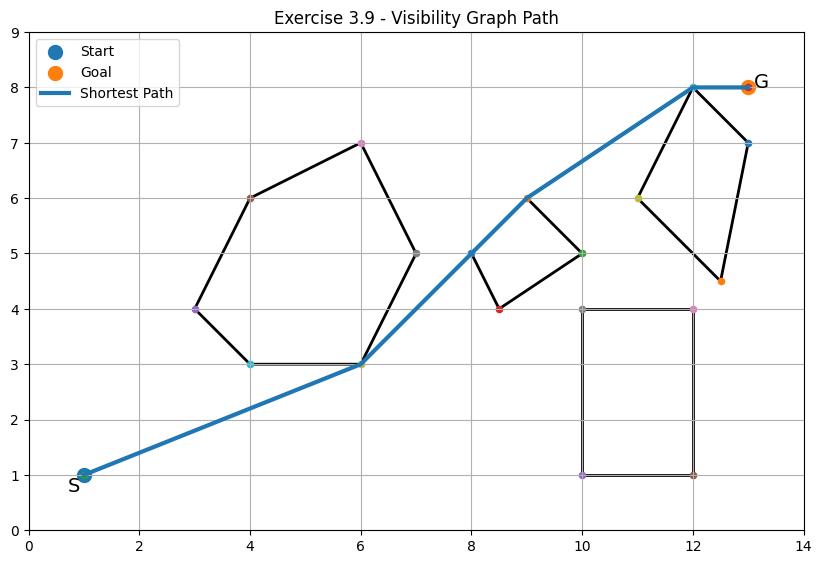

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))

# draw obstacles
for poly in obstacles:
    patch = Polygon(poly, fill=False, linewidth=2)
    ax.add_patch(patch)

# draw start and goal
ax.scatter(S[0],S[1],s=100,label="Start")
ax.scatter(G[0],G[1],s=100,label="Goal")

ax.text(S[0]-0.3,S[1]-0.3,"S",fontsize=14)
ax.text(G[0]+0.1,G[1],"G",fontsize=14)

# draw path
xs = [p[0] for p in path]
ys = [p[1] for p in path]

ax.plot(xs,ys,linewidth=3,label="Shortest Path")

# draw vertices
for v in vertices:
    ax.scatter(v[0],v[1],s=20)

ax.set_xlim(0,14)
ax.set_ylim(0,9)
ax.set_aspect("equal")
ax.grid(True)
ax.legend()
plt.title("Exercise 3.9 - Visibility Graph Path")
plt.show()

# PART 9 - PERFORMANCE COMMENTS

Performance Discussion:

1. BFS:
   - Finds fewest edges, not shortest metric path.

2. Uniform Cost Search:
   - Optimal but expands more nodes.

3. Greedy Best First:
   - Fast but may fail optimality.

4. A*:
   - Best choice here.
   - Uses straight-line heuristic.
   - Admissible and optimal.

Conclusion:
A* on visibility graph is efficient and exact.

# Exercise 3.11 - Missionaries and Cannibals problem

# PART 1 - THEORY ANSWERS

The missionaries and cannibals problem follows an approach to problem formulation when it comes to Ai. The problem is based on three missionaries and three cannibals which are on one side of a river, along with a boat that can hold one or two people. The goal is to get everyone to the other side without ever leaving a group of missionaries in one place outnumbered by the cannibals in that place.

The problem can be represented from a physical puzzle to a representation of mathematical states, where each missionary, cannibal and bank (boat position) are tracked as variables with values that represent their amount and position.
The variables are set in a tuple $(M, C, B)$ tracking the left bank's missionaries ($M$), cannibals ($C$), and boat position ($B=1$ for left, $B=0$ for right). Variables $M$ and $C$ range from 0 to 3 and relate to the amount of individuals of said category at that current state on one side of the river.
The initial state of the problem is $(3, 3, 1)$, where both groups are stranded on one side of the river, with the target goal state being $(0, 0, 0)$, successfully moving each group to the other side.
Movement is relegated to moving a certain $(m, c)$ amount of people across the river per change in state. This means that for the boat being capable of holding around 1 or 2 people ($1 \le m + c \le 2$), each state must satisfy the constraints of the problem, where missionaries cannot be outnumbered by cannibals on either side river. This means that for every valid boat loading quantities, of which are 1M, 2M, 1C, 2C, or 1M+1C, the movements should keep both sides of the river safe by avoiding the cannibals overpowering the missionaries. This means that the left bank of the river is safe if: $M \ge C$ or $M = 0$ and the right bank of the river is safe if: $(3 - M) \ge (3 - C)$ or $M = 3$

To formulate the problem graphically, a diagram was created with the graphviz library in order to visualize the problem.

# PART 2 - GRAPHICAL IMPLEMENTATION

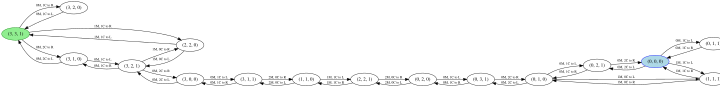

In [2]:
import graphviz
from collections import deque

def is_valid(state):
    m, c, b = state
    if m < 0 or m > 3 or c < 0 or c > 3: return False
    if m > 0 and m < c: return False
    right_m, right_c = 3 - m, 3 - c
    if right_m > 0 and right_m < right_c: return False
    return True

def get_successors(state):
    successors = []
    m, c, b = state
    moves = [(1, 0), (2, 0), (0, 1), (0, 2), (1, 1)]

    for dm, dc in moves:
        if b == 1:
            new_state = (m - dm, c - dc, 0)
        else:
            new_state = (m + dm, c + dc, 1)

        if is_valid(new_state):
            successors.append((new_state, (dm, dc, b)))
    return successors

# Creates and renders the graph
def draw_state_space():
    dot = graphviz.Digraph(comment='Missionaries and Cannibals')
    dot.attr(rankdir='LR', size='10,8')

    initial_state = (3, 3, 1)
    goal_state = (0, 0, 0)
    dot.node(str(initial_state), str(initial_state), color='green', style='filled', fillcolor='lightgreen')
    dot.node(str(goal_state), str(goal_state), color='blue', style='filled', fillcolor='lightblue')

    queue = deque([initial_state])
    visited = set([initial_state])
    edges_added = set()

    while queue:
        current_state = queue.popleft()

        if current_state != initial_state and current_state != goal_state:
            dot.node(str(current_state), str(current_state), shape='oval')

        for next_state, action in get_successors(current_state):
            dm, dc, old_b = action

            direction = "R" if old_b == 1 else "L"
            move_label = f"{dm}M, {dc}C to {direction}"

            edge_signature = (current_state, next_state, move_label)
            if edge_signature not in edges_added:
                dot.edge(str(current_state), str(next_state), label=move_label, fontsize='10')
                edges_added.add(edge_signature)

            if next_state not in visited:
                visited.add(next_state)
                queue.append(next_state)

    return dot
state_diagram = draw_state_space()
state_diagram

# PART 3 - SEARCH ALGORITHM

Implementing an optimal algorithm for the missionaries and cannibals problem would require determining how the boat movements affect the states of each group along the river. Considering that each boat trip counts as one full movement, regardless of the amount of people on the boat, the cost for each action would be only 1, where left to right and right to left are equal in movement value. Graphically, this means that the problem maps out as an unweighted graph, where each movement possibility is connected as a series of nodes that are treated equally due to their equal cost in movement. Moving 1C + 1M is equal to moving 2C or 2M, etc. Since cost of movement is not an issue for each possible movement opportunity, the best algorithm for the problem will require to simply search for the shortest physical sequence from the starting state $(3, 3, 1)$ to the end state $(0, 0, 0)$. As such, the best choice for the search algorithm for this problem will be the Breadth-First Search (BFS) algorithm, an algorithm that searches from level to level. Since the graph is unweighted and the movement of each trip cost the same, BFS can find the first instance of reaching the end state as the shortest possible sequence of moves, guaranteeing an optimal solution that follows the constraints of the problem. Other, more complicated search algorithmgs can be used, but given the simplicity of the states and traversal, BFS becomes the most optimal for finding the end state.

# PART 4 - BREADTH-FIRST SEARCH

In [ ]:
from collections import deque

def is_valid(m, c):
   #sets the boundaries for the amount of people on both groups
    if m < 0 or c < 0 or m > 3 or c > 3:
        return False
   # verifies if the constraints are not met
    if (m > 0 and m < c) or (3 - m > 0 and 3 - m < 3 - c):
        return False
    return True

def bfs():
    start = (3, 3, 1) # (Missionaries, Cannibals, Boat on Left)
    goal = (0, 0, 0)

    #Queue stores the paths.
    queue = deque([[start]])
    visited = set([start])
    moves = [(1,0), (2,0), (0,1), (0,2), (1,1)] # (M, C)

    while queue:
        path = queue.popleft()
        m, c, b = path[-1] # Determines the current state

        if (m, c, b) == goal:
            return path

        for dm, dc in moves:
            op = -1 if b == 1 else 1
            new_state = (m + (op * dm), c + (op * dc), 1 - b)

            if is_valid(new_state[0], new_state[1]) and new_state not in visited:
                visited.add(new_state)
                queue.append(path + [new_state])

    return None
for step in bfs():
    print(step)

# PART 5 - HUMAN SOLVING PUZZLE

The missionaries and cannibals problem is deceptively difficult for people due to the numerous constraints applied, the necessity of repetitive moves, and the fact that some moves appear counterintuitive. Because of these factors, humans often lead with choices that seem valid in the short-term but lead to dead-end states in the future, requiring for more extensive prediction at the cost of a more intense cognitive load. Additionally, people rarely approach the problem systematically as a state-space search problem, instead applying heuristics and short-sighted reasoning which are ill-suited for the exercise at hand. In summary, the difficulty arises not from the state space but instead from the problem's structure and how people typically apply problem-solving strategies.